# Lezione 2 — Dati tabellari clinici, explainability e incertezza

**Modulo 2.** Corso di AI applicata, Zucchetti Centro Sistemi.

Il notebook si esegue dall'alto in basso. Non serve GPU: il modello più lento
impiega una decina di secondi su CPU.

Tre celle sono marcate `PUNTO DI VARIAZIONE`: contengono una costante modificabile.

### Dati

**UCI Thyroid Disease**, task `sick`: 2.800 righe di training e 972 di test, 29
attributi. Sei esami di laboratorio — TSH, T3, TT4, T4U, FTI, TBG — ciascuno
preceduto dal proprio flag `*_measured`.

> Quinlan J. R. *Thyroid Disease.* UCI Machine Learning Repository, 1987.
> Dati raccolti dal Garavan Institute, Sydney.

Fonte: <https://archive.ics.uci.edu/dataset/102/thyroid+disease>, licenza
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

### Il filo

Si costruisce un modello, si arriva a un AUC di 0,999, e poi si smonta quel numero.
Le voci del programma che questo dataset non può reggere — il delta fra prelievi
successivi, la validazione temporale, la conformal prediction — restano sulle slide.

In [1]:
# Installazione e dati. Su Colab la prima esecuzione impiega circa un minuto.
import importlib, subprocess, sys, os, io, zipfile, urllib.request, pathlib, warnings
warnings.filterwarnings("ignore")

if importlib.util.find_spec("interpret") is None:
    print("installo interpret")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "interpret"], check=True)

URL = ("https://github.com/nunziati/zcs-ai-course-2026/releases/download/"
       "dati-thyroid/uci-thyroid.zip")
ROOT = pathlib.Path("dati")

if not (ROOT / "thyroid" / "sick.data").exists():
    ROOT.mkdir(exist_ok=True)
    print("download dei dati, 120 KB")
    with urllib.request.urlopen(URL) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(ROOT)

D = ROOT / "thyroid"

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.metrics import confusion_matrix

plt.rcParams["figure.dpi"] = 110
print(f"pandas {pd.__version__}, scikit-learn {sklearn.__version__}")
print("nessuna GPU richiesta")

download dei dati, 120 KB


pandas 3.0.5, scikit-learn 1.9.0
nessuna GPU richiesta


---

# Passo 2 — Dati

In [2]:
# I .data non hanno intestazione, i mancanti sono '?', e l'ultima colonna unisce
# la classe e l'id del record con una barra verticale: "negative.|3733".
COLONNE = ['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
           'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
           'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
           'goitre', 'tumor', 'hypopituitary', 'psych',
           'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4',
           'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG',
           'referral_source', 'target']

ESAMI = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
BOOLEANE = ['on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
            'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
            'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
            'tumor', 'hypopituitary', 'psych']

def carica(nome):
    d = pd.read_csv(D / nome, header=None, names=COLONNE, na_values="?")
    d["target"] = d["target"].str.split("|").str[0].str.rstrip(".")
    d["y"] = (d["target"] == "sick").astype(int)
    return d

train, test = carica("sick.data"), carica("sick.test")

# Attenzione al nome: 'sick' è sia una colonna di anamnesi sia il nome della classe
# positiva. La colonna è un dato del paziente, l'etichetta sta in 'target'.
print(f"train {len(train)} righe, {train.y.sum()} positivi "
      f"({train.y.mean():.1%}), sbilanciamento {(1 - train.y.mean()) / train.y.mean():.1f} : 1")
print(f"test  {len(test)} righe, {test.y.sum()} positivi ({test.y.mean():.1%})")
train.head(3)

train 2800 righe, 171 positivi (6.1%), sbilanciamento 15.4 : 1
test  972 righe, 60 positivi (6.2%)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,y
0,41.0,F,f,f,f,f,f,f,f,f,...,125.0,t,1.14,t,109.0,f,NaN,SVHC,negative,0
1,23.0,F,f,f,f,f,f,f,f,f,...,102.0,f,NaN,f,NaN,f,NaN,other,negative,0
2,46.0,M,f,f,f,f,f,f,f,f,...,109.0,t,0.91,t,120.0,f,NaN,other,negative,0


In [3]:
# Il missing non è rumore. Guarda la prevalenza condizionata al fatto che l'esame ci sia.
righe = []
for e in ESAMI:
    manca = train[e].isna()
    righe.append({"esame": e, "manca": int(manca.sum()), "% manca": 100 * manca.mean(),
                  "prevalenza se manca": train.y[manca].mean() if manca.any() else np.nan,
                  "prevalenza se misurato": train.y[~manca].mean() if (~manca).any() else np.nan})
print(f"prevalenza complessiva: {train.y.mean():.4f}\n")
print(pd.DataFrame(righe).set_index("esame").round(4).to_string())

# Il verso è il contrario dell'intuizione: se l'esame manca, il paziente è quasi
# sempre negativo. Non è un caso, è il meccanismo che genera i dati — l'esame lo
# prescrive un medico che ha già un sospetto.
manca_tt4 = train["TT4"].isna()
print(f"\nTT4 non misurato: {manca_tt4.sum()} righe, {train.y[manca_tt4].sum()} positivi")

# I flag *_measured coincidono esattamente con l'indicatore di mancanza.
incoerenze = {e: int(((train[e + "_measured"] == "t") != train[e].notna()).sum()) for e in ESAMI}
print("incoerenze fra flag e valore:", incoerenze)
print("L'indicatore di missing è già nel dataset, in chiaro, una colonna per esame.")

prevalenza complessiva: 0.0611

       manca   % manca  prevalenza se manca  prevalenza se misurato
esame                                                              
TSH      284   10.1429               0.0070                  0.0672
T3       585   20.8929               0.0034                  0.0763
TT4      184    6.5714               0.0000                  0.0654
T4U      297   10.6071               0.0168                  0.0663
FTI      295   10.5357               0.0169                  0.0663
TBG     2800  100.0000               0.0611                     NaN

TT4 non misurato: 184 righe, 0 positivi
incoerenze fra flag e valore: {'TSH': 0, 'T3': 0, 'TT4': 0, 'T4U': 0, 'FTI': 0, 'TBG': 0}
L'indicatore di missing è già nel dataset, in chiaro, una colonna per esame.


   righe  positivi  prevalenza
0   2029       162      0.0798
1    405         4      0.0099
2    178         5      0.0281
3      9         0      0.0000
4     38         0      0.0000
5    141         0      0.0000


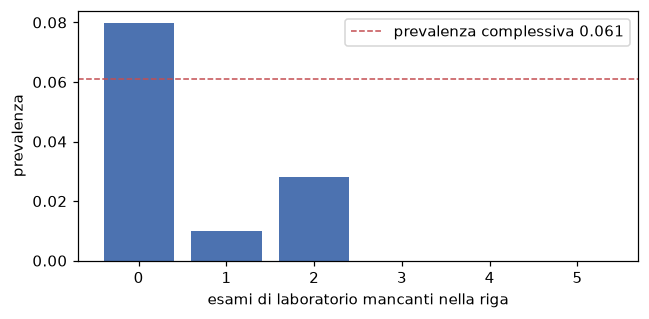

In [4]:
# Quanti esami mancano per riga, contro la prevalenza. TBG escluso: manca sempre.
k = train[["TSH", "T3", "TT4", "T4U", "FTI"]].isna().sum(axis=1)
per_k = pd.DataFrame({"righe": k.value_counts().sort_index(),
                      "positivi": train.groupby(k).y.sum(),
                      "prevalenza": train.groupby(k).y.mean()})
print(per_k.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(per_k.index, per_k["prevalenza"], color="#4c72b0")
ax.axhline(train.y.mean(), color="#c44e52", ls="--", lw=1,
           label=f"prevalenza complessiva {train.y.mean():.3f}")
ax.set_xlabel("esami di laboratorio mancanti nella riga")
ax.set_ylabel("prevalenza")
ax.legend()
plt.tight_layout(); plt.show()

In [5]:
# TBG manca nel 100% delle righe. Non è solo inutile: rompe una libreria.
print(f"TBG mancante: {train['TBG'].isna().mean():.1%} delle righe di training")

X_con_tbg = train[["age", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"]]
try:
    HistGradientBoostingClassifier(random_state=0).fit(X_con_tbg, train.y)
    print("HistGradientBoostingClassifier: nessun errore")
except Exception as errore:
    print(f"HistGradientBoostingClassifier -> {type(errore).__name__}: {errore}")

# Con la stessa colonna, gli altri reggono. È un limite del binning di scikit-learn,
# non una proprietà dei modelli ad alberi.
from sklearn.ensemble import RandomForestClassifier
RandomForestClassifier(n_estimators=50, random_state=0).fit(X_con_tbg.fillna(-1), train.y)
print("RandomForestClassifier: nessun errore")

TBG mancante: 100.0% delle righe di training
HistGradientBoostingClassifier -> ValueError: window shape cannot be larger than input array shape
RandomForestClassifier: nessun errore


In [6]:
# referral_source è il centro che ha inviato il paziente. Non è una feature qualsiasi.
def per_centro(d):
    return (d.groupby("referral_source").y
             .agg(righe="size", positivi="sum", prevalenza="mean")
             .sort_values("prevalenza"))

print("TRAIN\n" + per_centro(train).round(4).to_string())
print("\nTEST\n" + per_centro(test).round(4).to_string())
print("\nDa 0,0% a 17,9%. Il centro che invia il paziente predice la diagnosi meglio")
print("di metà degli esami, e non è un fatto clinico: è come sono stati raccolti i dati.")

TRAIN
                 righe  positivi  prevalenza
referral_source                             
STMW                91         0      0.0000
other             1632        25      0.0153
SVHC               275         5      0.0182
SVHD                31         3      0.0968
SVI                771       138      0.1790

TEST
                 righe  positivi  prevalenza
referral_source                             
STMW                21         0      0.0000
SVHD                 8         0      0.0000
other              569         8      0.0141
SVHC               111         4      0.0360
SVI                263        48      0.1825

Da 0,0% a 17,9%. Il centro che invia il paziente predice la diagnosi meglio
di metà degli esami, e non è un fatto clinico: è come sono stati raccolti i dati.


---

# Passo 3 — Dalla baseline al metodo

In [7]:
# PUNTO DI VARIAZIONE
# Come si trattano i valori mancanti: "mediana", "costante" oppure "nativo".
STRATEGIA_MISSING = "nativo"

CENTRI = ["SVI", "SVHC", "SVHD", "STMW", "other"]

def prepara(d, con_referral=True):
    """Matrice numerica. I mancanti restano NaN: li tratta il modello, o l'imputatore."""
    X = pd.DataFrame(index=d.index)
    X["age"] = d["age"]
    X["sex"] = np.where(d["sex"].isna(), np.nan, (d["sex"] == "F").astype(float))
    for c in BOOLEANE:
        X[c] = (d[c] == "t").astype(float)
    for c in ["TSH", "T3", "TT4", "T4U", "FTI"]:
        X[c] = d[c]
    if con_referral:
        for s in CENTRI:
            X["ref_" + s] = (d["referral_source"] == s).astype(float)
    return X

def applica_strategia(Xtr, Xte, strategia):
    """Restituisce le due matrici trattate secondo la strategia scelta."""
    if strategia == "nativo":
        return Xtr, Xte
    riempi = Xtr.median() if strategia == "mediana" else pd.Series(-1.0, index=Xtr.columns)
    return Xtr.fillna(riempi), Xte.fillna(riempi)

X_train, X_test = prepara(train), prepara(test)
y_train, y_test = train.y.values, test.y.values
print(f"{X_train.shape[1]} colonne, strategia sui mancanti: {STRATEGIA_MISSING}")

26 colonne, strategia sui mancanti: nativo


In [8]:
# La scala, dal lineare all'albero. Tutti sullo stesso split ufficiale.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def valuta(nome, p, y=None, mostra=True):
    y = y_test if y is None else y
    r = {"modello": nome, "AUC": roc_auc_score(y, p),
         "PR-AUC": average_precision_score(y, p), "Brier": brier_score_loss(y, p)}
    if mostra:
        print(f"{nome:38s} AUC {r['AUC']:.4f}   PR-AUC {r['PR-AUC']:.4f}   Brier {r['Brier']:.5f}")
    return r

def logistica(Xtr, Xte, strategia):
    a, b = applica_strategia(Xtr, Xte, strategia)
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(a, y_train)
    return m.predict_proba(b)[:, 1]

def con_indicatori(X):
    Z = X.copy()
    for c in ["TSH", "T3", "TT4", "T4U", "FTI"]:
        Z["manca_" + c] = X[c].isna().astype(float)
    return Z

risultati = [valuta("logistica, imputazione mediana", logistica(X_train, X_test, "mediana")),
             valuta("logistica, imputazione costante -1", logistica(X_train, X_test, "costante")),
             valuta("logistica, mediana + indicatori",
                    logistica(con_indicatori(X_train), con_indicatori(X_test), "mediana"))]

a, b = applica_strategia(X_train, X_test, STRATEGIA_MISSING)
hgb = HistGradientBoostingClassifier(random_state=0).fit(a, y_train)
p_hgb = hgb.predict_proba(b)[:, 1]
risultati.append(valuta("HistGradientBoosting, NaN nativi", p_hgb))

# Due letture, e sono diverse fra loro.
# 1. Imputare non è neutro: sostituire con -1 invece che con la mediana costa dieci
#    punti di AUC, sugli stessi dati e con lo stesso modello.
# 2. Gli indicatori espliciti non aggiungono niente alla logistica, perché il segnale
#    del missing è già passato dentro l'imputazione mediana, che ammassa le righe
#    mancanti in un punto solo. È l'albero a usare davvero quella struttura, perché
#    può separare "manca" da qualunque valore osservato.
print(f"\nmediana -> costante: {risultati[1]['AUC'] - risultati[0]['AUC']:+.4f} di AUC")
print(f"indicatori espliciti: {risultati[2]['AUC'] - risultati[0]['AUC']:+.4f} di AUC")
print(f"logistica migliore -> albero: {risultati[3]['AUC'] - max(r['AUC'] for r in risultati[:3]):+.4f}")

logistica, imputazione mediana         AUC 0.9685   PR-AUC 0.6891   Brier 0.02822
logistica, imputazione costante -1     AUC 0.8697   PR-AUC 0.3044   Brier 0.04980
logistica, mediana + indicatori        AUC 0.9686   PR-AUC 0.6844   Brier 0.02853


HistGradientBoosting, NaN nativi       AUC 0.9986   PR-AUC 0.9820   Brier 0.00766

mediana -> costante: -0.0988 di AUC
indicatori espliciti: +0.0002 di AUC
logistica migliore -> albero: +0.0299


In [9]:
# L'EBM: un modello additivo generalizzato addestrato a boosting, un termine per
# feature. Su questi dati impiega una decina di secondi su CPU.
import time
from interpret.glassbox import ExplainableBoostingClassifier

t0 = time.time()
ebm = ExplainableBoostingClassifier(random_state=0).fit(X_train, y_train)
p_ebm = ebm.predict_proba(X_test)[:, 1]
print(f"addestramento in {time.time() - t0:.1f} s")
risultati.append(valuta("EBM", p_ebm))

coppie = [t for t in ebm.term_names_ if "&" in t]
print(f"\ntermini appresi: {len(ebm.term_names_)}, su {X_train.shape[1]} colonne di ingresso")
print(f"di cui coppie di feature: {len(coppie)}; prime tre: {coppie[:3]}")
print("\nL'EBM non è puramente additivo per impostazione predefinita: aggiunge")
print("interazioni a coppie. Restano leggibili una per una, ma il numero di termini")
print("da guardare non è più il numero di feature.")

addestramento in 9.0 s
EBM                                    AUC 0.9944   PR-AUC 0.9444   Brier 0.01080

termini appresi: 104, su 26 colonne di ingresso
di cui coppie di feature: 78; prime tre: ['age & sex', 'age & on_thyroxine', 'age & query_hypothyroid']

L'EBM non è puramente additivo per impostazione predefinita: aggiunge
interazioni a coppie. Restano leggibili una per una, ma il numero di termini
da guardare non è più il numero di feature.


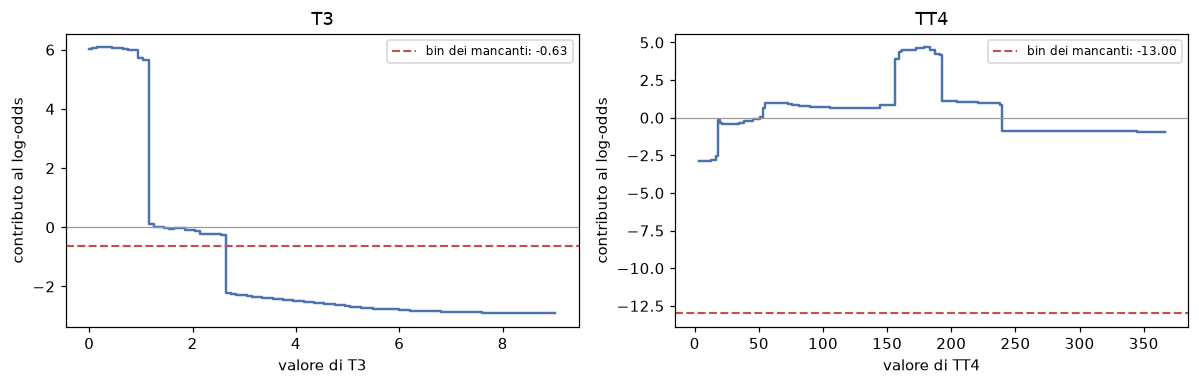

T3, contributo del bin dei mancanti      : -0.630
T3, contributo massimo fra i bin osservati: +6.079

Il modello tiene il missing in un bin a sé, e quel bin ha un peso stimato,
non ereditato da una scelta di imputazione fatta a monte.


In [10]:
# La forma appresa per un esame, presa dal modello e disegnata a mano.
# term_scores_[i] ha in posizione 0 il bin dei mancanti, in ultima posizione il bin
# dei valori mai visti, e in mezzo un punteggio per ogni intervallo.
def forma(termine, ax):
    i = ebm.term_names_.index(termine)
    punteggi = ebm.term_scores_[i][1:-1]
    tagli = np.asarray(ebm.bins_[i][0], dtype=float)
    # len(punteggi) == len(tagli) + 1: il primo bin sta sotto il primo taglio,
    # l'ultimo sopra l'ultimo. Per il disegno si estendono i due estremi.
    passo = np.diff(tagli).mean()
    bordi = np.concatenate([[tagli[0] - passo], tagli, [tagli[-1] + passo]])
    centri = (bordi[:-1] + bordi[1:]) / 2
    ax.step(centri, punteggi, where="mid", color="#4c72b0", lw=1.6)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.axhline(ebm.term_scores_[i][0], color="#c44e52", ls="--", lw=1.4,
               label=f"bin dei mancanti: {ebm.term_scores_[i][0]:+.2f}")
    ax.set_title(termine); ax.set_xlabel(f"valore di {termine}")
    ax.set_ylabel("contributo al log-odds"); ax.legend(fontsize=8)

fig, assi = plt.subplots(1, 2, figsize=(11, 3.6))
forma("T3", assi[0]); forma("TT4", assi[1])
plt.tight_layout(); plt.show()

i = ebm.term_names_.index("T3")
print(f"T3, contributo del bin dei mancanti      : {ebm.term_scores_[i][0]:+.3f}")
print(f"T3, contributo massimo fra i bin osservati: {ebm.term_scores_[i][1:-1].max():+.3f}")
print("\nIl modello tiene il missing in un bin a sé, e quel bin ha un peso stimato,")
print("non ereditato da una scelta di imputazione fatta a monte.")

In [11]:
# Tre classifiche di importanza sullo stesso problema. Non concordano.
from sklearn.inspection import permutation_importance
import lightgbm as lgb

imp_ebm = pd.Series({t: float(np.abs(ebm.term_scores_[i][1:-1]).mean())
                     for i, t in enumerate(ebm.term_names_)
                     if "&" not in t}).sort_values(ascending=False)

perm = permutation_importance(hgb, b, y_test, n_repeats=10, random_state=0, scoring="roc_auc")
imp_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

gbm = lgb.LGBMClassifier(verbose=-1, random_state=0).fit(X_train, y_train)
imp_gain = pd.Series(gbm.booster_.feature_importance("gain"),
                     index=X_train.columns).sort_values(ascending=False)

classifica = pd.DataFrame({"EBM": imp_ebm.rank(ascending=False),
                           "permutazione": imp_perm.rank(ascending=False),
                           "gain LightGBM": imp_gain.rank(ascending=False)})
print(classifica.loc[imp_gain.index[:8]].astype(int).to_string())
print("\nprime tre per ciascun metodo:")
for nome, s in [("EBM", imp_ebm), ("permutazione", imp_perm), ("gain", imp_gain)]:
    print(f"  {nome:13s} {list(s.index[:3])}")
print("\nT3 è primo per tutti e tre. Sotto, l'ordine cambia: T4U è terzo per l'EBM e")
print("settimo per il gain, ref_SVI quarto per la permutazione e undicesimo per l'EBM.")
print("Non c'è un metodo giusto: misurano cose diverse, e vanno chiamate per nome.")

           EBM  permutazione  gain LightGBM
T3           1             1              1
TT4          2             3              2
FTI          6             2              3
TSH          5             5              4
ref_other   13             7              5
age         15             9              6
T4U          3             6              7
ref_SVI     11             4              8

prime tre per ciascun metodo:
  EBM           ['T3', 'TT4', 'T4U']
  permutazione  ['T3', 'FTI', 'TT4']
  gain          ['T3', 'TT4', 'FTI']

T3 è primo per tutti e tre. Sotto, l'ordine cambia: T4U è terzo per l'EBM e
settimo per il gain, ref_SVI quarto per la permutazione e undicesimo per l'EBM.
Non c'è un metodo giusto: misurano cose diverse, e vanno chiamate per nome.


---

# Passo 4 — Valutazione

In [12]:
# Il numero che si porterebbe in riunione.
print(f"AUC sul test ufficiale: {roc_auc_score(y_test, p_hgb):.4f}")

SOGLIA = 0.5
(vn, fp), (fn, vp) = confusion_matrix(y_test, (p_hgb >= SOGLIA).astype(int))
print(f"\nalla soglia {SOGLIA}:")
print(f"  veri negativi  {vn:4d}   falsi positivi {fp:4d}")
print(f"  falsi negativi {fn:4d}   veri positivi  {vp:4d}")
print(f"\nsensibilità {vp / (vp + fn):.3f}, specificità {vn / (vn + fp):.3f}")
print(f"\nCon un AUC di {roc_auc_score(y_test, p_hgb):.4f} il modello lascia passare")
print(f"{fn} malati su {vp + fn}. Discriminare e essere utili sono due domande diverse.")

AUC sul test ufficiale: 0.9986

alla soglia 0.5:
  veri negativi   911   falsi positivi    1
  falsi negativi    7   veri positivi    53

sensibilità 0.883, specificità 0.999

Con un AUC di 0.9986 il modello lascia passare
7 malati su 60. Discriminare e essere utili sono due domande diverse.


In [13]:
# Perché quel numero è così alto. Un albero di profondità due, su due soli esami,
# limitato alle righe in cui T3 è stato misurato.
from sklearn.tree import DecisionTreeClassifier, export_text

due = ["T3", "TT4"]
tr_oss, te_oss = train[train.T3.notna()], test[test.T3.notna()]
albero = DecisionTreeClassifier(max_depth=2, random_state=0).fit(tr_oss[due], tr_oss.y)
p_albero = albero.predict_proba(te_oss[due])[:, 1]

print(f"righe con T3 misurato: {len(tr_oss)} in train, {len(te_oss)} in test "
      f"({te_oss.y.sum()} positivi su {test.y.sum()})")
print(f"albero di profondità 2 su T3 e TT4: AUC {roc_auc_score(te_oss.y, p_albero):.4f}\n")
print(export_text(albero, feature_names=due, show_weights=True))

foglie = albero.apply(tr_oss[due].values)
for f in np.unique(foglie):
    m = foglie == f
    print(f"foglia {f}: {m.sum():4d} righe, {tr_oss.y.values[m].sum():3d} positivi, "
          f"prevalenza {tr_oss.y.values[m].mean():.3f}")

print("\nUna foglia sola, T3 basso e TT4 non bassissimo, contiene 145 dei 169 malati")
print("del training. La classe positiva di questo dataset è la sindrome del malato")
print("eutiroideo, che in clinica si definisce a partire dai valori di laboratorio:")
print("l'etichetta è una funzione degli stessi esami che passiamo in ingresso.")
print("Il modello sta imparando la definizione della diagnosi, non a prevederla.")
print("\nPrima di festeggiare un AUC, la domanda è chi ha prodotto l'etichetta e con cosa.")

righe con T3 misurato: 2215 in train, 788 in test (59 positivi su 60)
albero di profondità 2 su T3 e TT4: AUC 0.9798

|--- T3 <= 1.15
|   |--- TT4 <= 53.00
|   |   |--- weights: [39.00, 4.00] class: 0
|   |--- TT4 >  53.00
|   |   |--- weights: [30.00, 145.00] class: 1
|--- T3 >  1.15
|   |--- TT4 <= 156.50
|   |   |--- weights: [1811.00, 5.00] class: 0
|   |--- TT4 >  156.50
|   |   |--- weights: [166.00, 15.00] class: 0

foglia 2:   43 righe,   4 positivi, prevalenza 0.093
foglia 3:  175 righe, 145 positivi, prevalenza 0.829
foglia 5: 1816 righe,   5 positivi, prevalenza 0.003
foglia 6:  181 righe,  15 positivi, prevalenza 0.083

Una foglia sola, T3 basso e TT4 non bassissimo, contiene 145 dei 169 malati
del training. La classe positiva di questo dataset è la sindrome del malato
eutiroideo, che in clinica si definisce a partire dai valori di laboratorio:
l'etichetta è una funzione degli stessi esami che passiamo in ingresso.
Il modello sta imparando la definizione della diagnosi, non

In [14]:
# Con 60 positivi, quanto vale la terza cifra decimale. Bootstrap sul test.
def intervallo(y, p, metrica, ripetizioni=2000, seme=0):
    rng = np.random.default_rng(seme)
    indici = np.arange(len(y))
    valori = []
    for _ in range(ripetizioni):
        s = rng.choice(indici, len(indici), replace=True)
        if y[s].sum() < 2:
            continue
        valori.append(metrica(y[s], p[s]))
    return np.percentile(valori, [2.5, 97.5])

sensibilita = lambda y, p: ((p >= 0.5) & (y == 1)).sum() / max((y == 1).sum(), 1)

for nome, metrica in [("AUC", roc_auc_score), ("sensibilità a 0,5", sensibilita)]:
    lo, hi = intervallo(y_test, p_hgb, metrica)
    print(f"{nome:20s} {metrica(y_test, p_hgb):.4f}   IC 95% [{lo:.4f}, {hi:.4f}]"
          f"   ampiezza {hi - lo:.4f}")

print("\nL'AUC ha un intervallo stretto, perché le classi sono quasi separate. La")
print("sensibilità, che è la quantità di cui risponde il clinico, ha un intervallo")
print("largo sedici punti, e dipende da sette pazienti.")

AUC                  0.9986   IC 95% [0.9969, 0.9997]   ampiezza 0.0028
sensibilità a 0,5    0.8833   IC 95% [0.7963, 0.9615]   ampiezza 0.1653

L'AUC ha un intervallo stretto, perché le classi sono quasi separate. La
sensibilità, che è la quantità di cui risponde il clinico, ha un intervallo
largo sedici punti, e dipende da sette pazienti.


In [15]:
# Confronto fra modelli: la differenza va misurata sullo stesso ricampionamento.
import xgboost as xgb, itertools

modelli = {"HistGB": p_hgb,
           "LightGBM": gbm.predict_proba(X_test)[:, 1],
           "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=0)
                         .fit(X_train, y_train).predict_proba(X_test)[:, 1],
           "EBM": p_ebm}

def differenza_auc(a, b, ripetizioni=2000, seme=0):
    rng = np.random.default_rng(seme)
    indici = np.arange(len(y_test))
    d = []
    for _ in range(ripetizioni):
        s = rng.choice(indici, len(indici), replace=True)
        if y_test[s].sum() < 2:
            continue
        d.append(roc_auc_score(y_test[s], a[s]) - roc_auc_score(y_test[s], b[s]))
    return np.percentile(d, [2.5, 97.5])

for x, z in itertools.combinations(modelli, 2):
    punto = roc_auc_score(y_test, modelli[x]) - roc_auc_score(y_test, modelli[z])
    lo, hi = differenza_auc(modelli[x], modelli[z])
    print(f"{x:9s} - {z:9s} = {punto:+.4f}   IC 95% [{lo:+.4f}, {hi:+.4f}]   "
          f"{'distinguibili' if lo * hi > 0 else 'non distinguibili'}")

print("\nLe tre implementazioni di gradient boosting non sono distinguibili fra loro su")
print("questo test. L'EBM sta sotto di quattro millesimi, e quella differenza si misura:")
print("è il prezzo, quantificato, delle curve leggibili di due celle fa.")

HistGB    - LightGBM  = -0.0003   IC 95% [-0.0011, +0.0002]   non distinguibili


HistGB    - XGBoost   = +0.0000   IC 95% [-0.0010, +0.0010]   non distinguibili


HistGB    - EBM       = +0.0042   IC 95% [+0.0006, +0.0102]   distinguibili


LightGBM  - XGBoost   = +0.0004   IC 95% [-0.0006, +0.0016]   non distinguibili


LightGBM  - EBM       = +0.0046   IC 95% [+0.0008, +0.0111]   distinguibili


XGBoost   - EBM       = +0.0042   IC 95% [+0.0006, +0.0099]   distinguibili

Le tre implementazioni di gradient boosting non sono distinguibili fra loro su
questo test. L'EBM sta sotto di quattro millesimi, e quella differenza si misura:
è il prezzo, quantificato, delle curve leggibili di due celle fa.


positivi disponibili per calibrare: 43


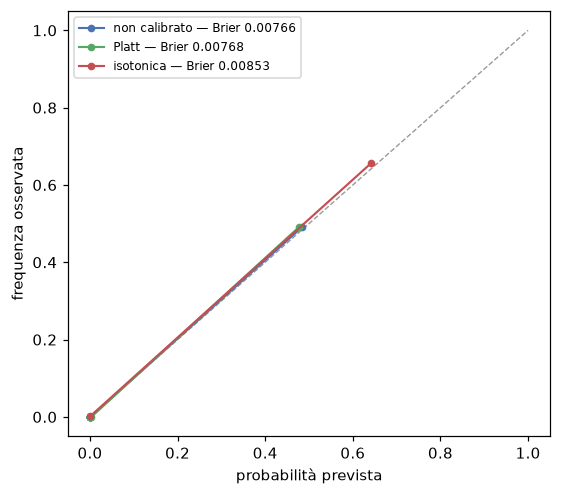

non calibrato   AUC 0.9979   Brier 0.00766   valori distinti  273
Platt           AUC 0.9979   Brier 0.00768   valori distinti  610
isotonica       AUC 0.9901   Brier 0.00853   valori distinti   14

Platt è strettamente monotona: nessuna coppia cambia ordine e l'AUC resta
identica alla quarta cifra. L'isotonica è monotona ma non stretta: con 43
positivi collassa le probabilità in poche decine di livelli, crea pareggi e
l'AUC scende. La ricalibrazione cambia il numero e non l'ordinamento, ma solo
finché resta strettamente monotona.


In [16]:
# La calibrazione. Calibrare richiede dati che il modello non ha visto, quindi da qui
# in avanti il modello è riaddestrato sul 75% del training e calibrato sul restante
# 25%. I numeri non coincidono con quelli delle celle precedenti, ed è per questo.
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

X_a, X_cal, y_a, y_cal = train_test_split(X_train, y_train, test_size=0.25,
                                          stratify=y_train, random_state=0)
modello = HistGradientBoostingClassifier(random_state=0).fit(X_a, y_a)
p_cal, p_te = modello.predict_proba(X_cal)[:, 1], modello.predict_proba(X_test)[:, 1]
print(f"positivi disponibili per calibrare: {int(y_cal.sum())}")

def platt(p_fit, y_fit, p_da_correggere):
    logit = lambda q: np.log(np.clip(q, 1e-6, 1 - 1e-6) / (1 - np.clip(q, 1e-6, 1 - 1e-6)))
    m = LogisticRegression().fit(logit(p_fit).reshape(-1, 1), y_fit)
    return m.predict_proba(logit(p_da_correggere).reshape(-1, 1))[:, 1]

p_platt = platt(p_cal, y_cal, p_te)
p_iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, y_cal).predict(p_te)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], color="0.6", lw=0.9, ls="--")
for nome, p, colore in [("non calibrato", p_te, "#4c72b0"),
                        ("Platt", p_platt, "#55a868"),
                        ("isotonica", p_iso, "#c44e52")]:
    v, m = calibration_curve(y_test, p, n_bins=8, strategy="quantile")
    ax.plot(m, v, "o-", color=colore, lw=1.4, ms=4,
            label=f"{nome} — Brier {brier_score_loss(y_test, p):.5f}")
ax.set_xlabel("probabilità prevista"); ax.set_ylabel("frequenza osservata")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

for nome, p in [("non calibrato", p_te), ("Platt", p_platt), ("isotonica", p_iso)]:
    print(f"{nome:15s} AUC {roc_auc_score(y_test, p):.4f}   "
          f"Brier {brier_score_loss(y_test, p):.5f}   "
          f"valori distinti {len(np.unique(np.round(p, 6))):4d}")

print("\nPlatt è strettamente monotona: nessuna coppia cambia ordine e l'AUC resta")
print("identica alla quarta cifra. L'isotonica è monotona ma non stretta: con 43")
print("positivi collassa le probabilità in poche decine di livelli, crea pareggi e")
print("l'AUC scende. La ricalibrazione cambia il numero e non l'ordinamento, ma solo")
print("finché resta strettamente monotona.")

In [17]:
# Cosa si rompe quando cambia la prevalenza, e cosa no.
def ricampiona_a(prevalenza, y, p, seme=0):
    """Sottocampiona la classe che serve per arrivare alla prevalenza voluta."""
    rng = np.random.default_rng(seme)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    if prevalenza < y.mean():
        quanti = int(round(len(neg) * prevalenza / (1 - prevalenza)))
        scelti = np.concatenate([rng.choice(pos, quanti, replace=False), neg])
    else:
        quanti = int(round(len(pos) * (1 - prevalenza) / prevalenza))
        scelti = np.concatenate([pos, rng.choice(neg, quanti, replace=False)])
    return y[scelti], p[scelti]

def correggi_prevalenza(p, prev_vecchia, prev_nuova):
    """Prior shift: se cambia solo la prevalenza, basta spostare l'intercetta."""
    q = np.clip(p, 1e-6, 1 - 1e-6)
    odds = q / (1 - q)
    fattore = (prev_nuova / (1 - prev_nuova)) / (prev_vecchia / (1 - prev_vecchia))
    return (odds * fattore) / (1 + odds * fattore)

print(f"{'popolazione':<26s} {'righe':>6s} {'prevalenza':>11s} {'AUC':>8s} {'Brier':>9s} {'p media':>9s}")
def riga(nome, y, p):
    print(f"{nome:<26s} {len(y):>6d} {y.mean():>11.4f} {roc_auc_score(y, p):>8.4f} "
          f"{brier_score_loss(y, p):>9.5f} {p.mean():>9.4f}")

riga("test originale", y_test, p_platt)
for pi in (0.02, 0.18):
    ys, ps = ricampiona_a(pi, y_test, p_platt)
    riga(f"prevalenza {pi:.2f}", ys, ps)
    riga(f"  dopo la correzione", ys, correggi_prevalenza(ps, y_test.mean(), ys.mean()))

print("\nL'AUC quasi non si muove: dipende solo dall'ordinamento, e l'ordinamento non")
print("cambia se si toglie una parte di una classe. Il Brier e la probabilità media sì.")
print("Quando un modello 'smette di funzionare' in produzione, quasi sempre è questo,")
print("e la correzione è chiusa. Richiede però di conoscere la nuova prevalenza, che")
print("si conosce solo se le etichette tornano indietro: è il problema del Passo 5.")

popolazione                 righe  prevalenza      AUC     Brier   p media
test originale                972      0.0617   0.9979   0.00768    0.0606
prevalenza 0.02               931      0.0204   0.9966   0.00517    0.0255
  dopo la correzione          931      0.0204   0.9966   0.00446    0.0192
prevalenza 0.18               333      0.1802   0.9962   0.01948    0.1651
  dopo la correzione          333      0.1802   0.9962   0.01691    0.1846

L'AUC quasi non si muove: dipende solo dall'ordinamento, e l'ordinamento non
cambia se si toglie una parte di una classe. Il Brier e la probabilità media sì.
Quando un modello 'smette di funzionare' in produzione, quasi sempre è questo,
e la correzione è chiusa. Richiede però di conoscere la nuova prevalenza, che
si conosce solo se le etichette tornano indietro: è il problema del Passo 5.


In [18]:
# PUNTO DI VARIAZIONE
# Il centro tenuto fuori dall'addestramento e usato come validazione esterna.
CENTRO_ESCLUSO = "SVI"

fuori_tr = train.referral_source != CENTRO_ESCLUSO
dentro_te = test.referral_source == CENTRO_ESCLUSO

# referral_source resta fuori dalle feature: qui interessa la generalizzazione a un
# centro mai visto, non la capacità di riconoscere quale centro sia.
esterno = HistGradientBoostingClassifier(random_state=0).fit(
    prepara(train[fuori_tr], con_referral=False), y_train[fuori_tr.values])
p_est = esterno.predict_proba(prepara(test[dentro_te], con_referral=False))[:, 1]
y_est = y_test[dentro_te.values]

interno = HistGradientBoostingClassifier(random_state=0).fit(
    prepara(train, con_referral=False), y_train)
p_int = interno.predict_proba(prepara(test, con_referral=False))[:, 1]

print(f"validazione interna : {len(y_test):4d} righe, prevalenza {y_test.mean():.4f}, "
      f"AUC {roc_auc_score(y_test, p_int):.4f}, Brier {brier_score_loss(y_test, p_int):.5f}")
print(f"validazione esterna : {len(y_est):4d} righe di {CENTRO_ESCLUSO}, "
      f"prevalenza {y_est.mean():.4f}, AUC {roc_auc_score(y_est, p_est):.4f}, "
      f"Brier {brier_score_loss(y_est, p_est):.5f}")
print(f"\nprevalenza nel training senza {CENTRO_ESCLUSO}: {y_train[fuori_tr.values].mean():.4f}"
      f"   in {CENTRO_ESCLUSO}: {y_est.mean():.4f}")
print(f"il Brier peggiora di {brier_score_loss(y_est, p_est) / brier_score_loss(y_test, p_int):.0f} volte")
print("\nÈ la stessa cosa della cella precedente, ma qui la prevalenza non l'abbiamo")
print("cambiata noi: era già diversa nei dati, e nessuno l'aveva guardata.")

validazione interna :  972 righe, prevalenza 0.0617, AUC 0.9967, Brier 0.01324
validazione esterna :  263 righe di SVI, prevalenza 0.1825, AUC 0.9276, Brier 0.14067

prevalenza nel training senza SVI: 0.0163   in SVI: 0.1825
il Brier peggiora di 11 volte

È la stessa cosa della cella precedente, ma qui la prevalenza non l'abbiamo
cambiata noi: era già diversa nei dati, e nessuno l'aveva guardata.


In [19]:
# PUNTO DI VARIAZIONE
# Quanto costa non vedere un malato, rispetto a un allarme sbagliato.
COSTO_FN_SU_FP = 10

soglia_costo = 1 / (1 + COSTO_FN_SU_FP)

def conta(p, s):
    return (int(((p >= s) & (y_test == 1)).sum()),
            int(((p < s) & (y_test == 1)).sum()),
            int(((p >= s) & (y_test == 0)).sum()))

print(f"{'costo FN/FP':>12s} {'soglia':>8s} {'VP':>4s} {'FN':>4s} {'FP':>4s} {'sensibilità':>12s}")
for rapporto in (1, 5, 10, 20, 50):
    vp, fn, fp = conta(p_platt, 1 / (1 + rapporto))
    print(f"{rapporto:>12d} {1 / (1 + rapporto):>8.4f} {vp:>4d} {fn:>4d} {fp:>4d} "
          f"{vp / (vp + fn):>12.3f}")

from sklearn.metrics import f1_score
soglie = np.unique(np.round(p_platt, 4))
migliore = max(soglie, key=lambda s: f1_score(y_test, p_platt >= s))
vp, fn, fp = conta(p_platt, migliore)
print(f"\nsoglia che massimizza F1: {migliore:.4f}, sensibilità {vp / (vp + fn):.3f}, "
      f"FP {fp}")
print(f"equivale ad aver posto il costo di un malato mancato a circa "
      f"{1 / migliore - 1:.0f} volte quello di un allarme sbagliato")
print("\nMassimizzare F1 non evita la scelta clinica: la fa, e la nasconde dentro una")
print("metrica. Il rapporto di costo qui sopra almeno è scritto, e si può discutere.")

 costo FN/FP   soglia   VP   FN   FP  sensibilità
           1   0.5000   55    5    4        0.917
           5   0.1667   58    2   13        0.967
          10   0.0909   58    2   15        0.967
          20   0.0476   59    1   24        0.983
          50   0.0196   59    1   35        0.983

soglia che massimizza F1: 0.3258, sensibilità 0.967, FP 5
equivale ad aver posto il costo di un malato mancato a circa 2 volte quello di un allarme sbagliato

Massimizzare F1 non evita la scelta clinica: la fa, e la nasconde dentro una
metrica. Il rapporto di costo qui sopra almeno è scritto, e si può discutere.


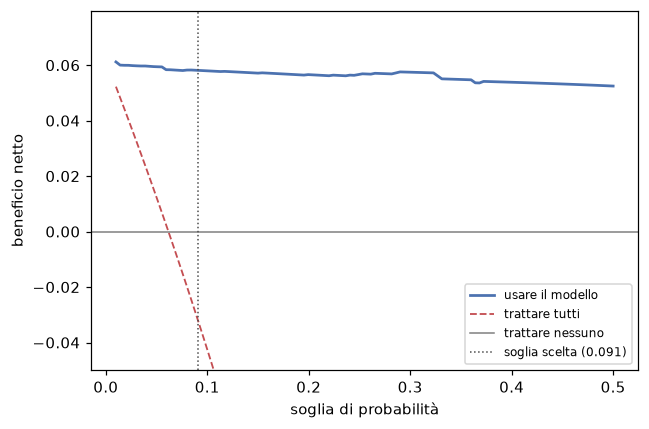

alla soglia 0.0909: modello 0.05813, trattare tutti -0.03210

Il modello sta sopra le due strategie banali su tutto l'intervallo utile.
È l'unica misura di questo notebook che risponde alla terza domanda: non se
il modello discrimina, non se è calibrato, ma se conviene usarlo.


In [20]:
# Il beneficio netto: mette soglia e prevalenza nella stessa unità di misura.
def beneficio_netto(y, p, soglia):
    n = len(y)
    vp = ((p >= soglia) & (y == 1)).sum()
    fp = ((p >= soglia) & (y == 0)).sum()
    return vp / n - (fp / n) * (soglia / (1 - soglia))

griglia = np.linspace(0.01, 0.5, 120)
nb_modello = [beneficio_netto(y_test, p_platt, s) for s in griglia]
nb_tutti = [beneficio_netto(y_test, np.ones_like(p_platt), s) for s in griglia]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(griglia, nb_modello, color="#4c72b0", lw=1.8, label="usare il modello")
ax.plot(griglia, nb_tutti, color="#c44e52", lw=1.2, ls="--", label="trattare tutti")
ax.axhline(0, color="0.5", lw=1, label="trattare nessuno")
ax.axvline(soglia_costo, color="0.3", lw=1, ls=":", label=f"soglia scelta ({soglia_costo:.3f})")
ax.set_xlabel("soglia di probabilità"); ax.set_ylabel("beneficio netto")
ax.set_ylim(-0.05, max(nb_modello) * 1.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"alla soglia {soglia_costo:.4f}: modello {beneficio_netto(y_test, p_platt, soglia_costo):.5f}, "
      f"trattare tutti {beneficio_netto(y_test, np.ones_like(p_platt), soglia_costo):.5f}")
print("\nIl modello sta sopra le due strategie banali su tutto l'intervallo utile.")
print("È l'unica misura di questo notebook che risponde alla terza domanda: non se")
print("il modello discrimina, non se è calibrato, ma se conviene usarlo.")

---

## Cosa resta

Il notebook ha percorso tre Passi su cinque, su un dataset solo.

Il **missing è informativo**, e il verso è il contrario di quello che ci si aspetta:
qui un esame che manca dice che il paziente sta bene, perché a prescriverlo è un
medico che ha già un sospetto. L'indicatore di mancanza era già nei dati, in chiaro,
una colonna per esame.

Sul **modello**, le tre implementazioni di gradient boosting non sono distinguibili
fra loro su questo test, e l'EBM costa quattro millesimi di AUC in cambio di curve
che si leggono una per una, bin dei mancanti compreso. Le tre classifiche di
importanza concordano solo sulla prima feature.

La **valutazione** è dove il notebook cambia direzione. L'AUC di 0,999 misura come è
stata costruita l'etichetta, non l'utilità clinica: una foglia di un albero di
profondità due contiene 145 dei 169 malati del training. Alla soglia 0,5 restano
sette malati non visti su sessanta, e l'intervallo di confidenza della sensibilità è
largo sedici punti. La ricalibrazione sposta le probabilità senza toccare
l'ordinamento, finché resta strettamente monotona. Quello che si rompe passando da un
centro all'altro è la calibrazione, non la discriminazione.

Tre voci del programma non stanno su questo dataset e restano sulle slide: il delta
fra prelievi successivi, la validazione temporale, e la conformal prediction, che con
43 positivi in calibrazione non produce insiemi utilizzabili.

**La domanda da portare alla sessione delle 12:30**: nei dati di laboratorio di ZCS,
chi produce l'etichetta, con quali misure, e quelle misure finiscono anche fra le
feature?